# Visualizing Data with Box Plots

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook uses box plots to visualize data distributions, identify outliers, and compare groups across various dimensions in the developer survey data.

## Setting Up the Database

First, I'll download the SQLite database file.

In [17]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"
output_file = "survey-data.sqlite"

response = requests.get(url, stream=True)

with open(output_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Download completed")

Download completed


## Importing Libraries

I'll import the necessary libraries for database operations and visualization.

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Connecting to the Database

Now I'll connect to the SQLite database.

In [19]:
# Connect to SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Auto-detect the actual table name
import pandas as pd
tables_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
TABLE_NAME = tables_df['name'][0]  # use the first table found
print("✅ Database connection established")
print(f"Using table: {TABLE_NAME}")

✅ Database connection established
Using table: main


## Verifying the Database

Let me run some basic queries to verify the database.

In [20]:
# Count total rows
QUERY = f"SELECT COUNT(*) as Total FROM {TABLE_NAME}"
df = pd.read_sql_query(QUERY, conn)
print(f"Total records: {df['Total'][0]}")

Total records: 65437


In [21]:
# List all tables
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
tables = pd.read_sql_query(QUERY, conn)
print("Tables in database:")
print(tables)

Tables in database:
  Table_Name
0       main


In [22]:
# Group data by age
QUERY = f"""
SELECT Age, COUNT(*) as count 
FROM {TABLE_NAME} 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print("Age distribution:")
print(df_age)

Age distribution:
                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Task 1: Visualizing Distribution of Data

### Box Plot 1: Total Compensation Distribution

I'll create a box plot to analyze the distribution and outliers in total compensation.

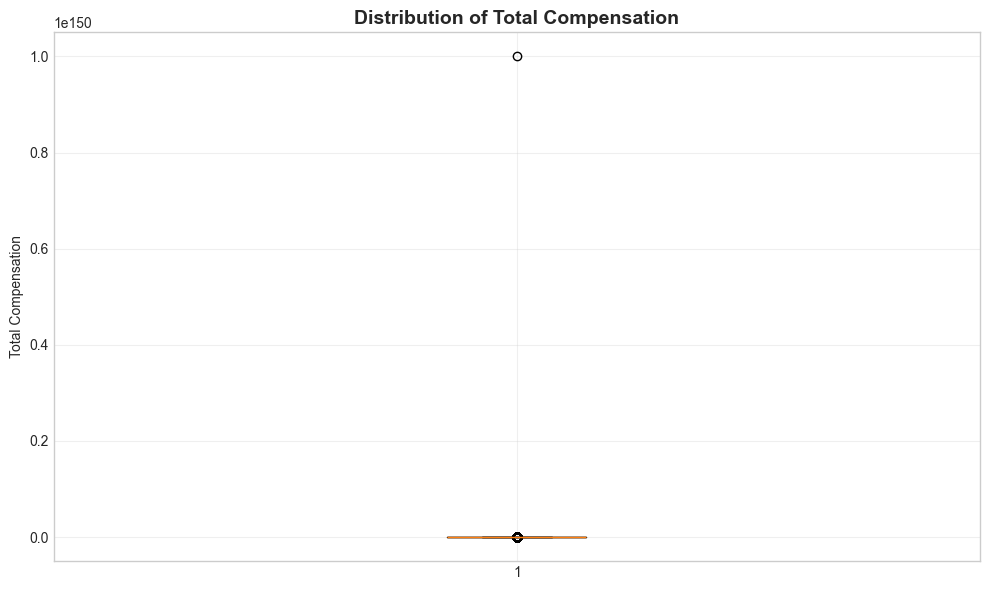

Count: 33740
Median: 110,000.00
Q1 (25%): 60,000.00
Q3 (75%): 250,000.00


In [23]:
# Query compensation data
QUERY = f"""
SELECT CompTotal 
FROM {TABLE_NAME} 
WHERE CompTotal IS NOT NULL
"""
comp_data = pd.read_sql_query(QUERY, conn)

# Convert to numeric (fixes the box plot)
comp_data['CompTotal'] = pd.to_numeric(comp_data['CompTotal'], errors='coerce')
comp_data = comp_data.dropna()

# Create box plot
plt.figure(figsize=(10, 6))
plt.boxplot(comp_data['CompTotal'], vert=True)
plt.title('Distribution of Total Compensation', fontsize=14, fontweight='bold')
plt.ylabel('Total Compensation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show statistics
print(f"Count: {len(comp_data)}")
print(f"Median: {comp_data['CompTotal'].median():,.2f}")
print(f"Q1 (25%): {comp_data['CompTotal'].quantile(0.25):,.2f}")
print(f"Q3 (75%): {comp_data['CompTotal'].quantile(0.75):,.2f}")

### Box Plot 2: Age Distribution (Numeric Values)

I'll convert age ranges to numeric values and visualize the distribution.

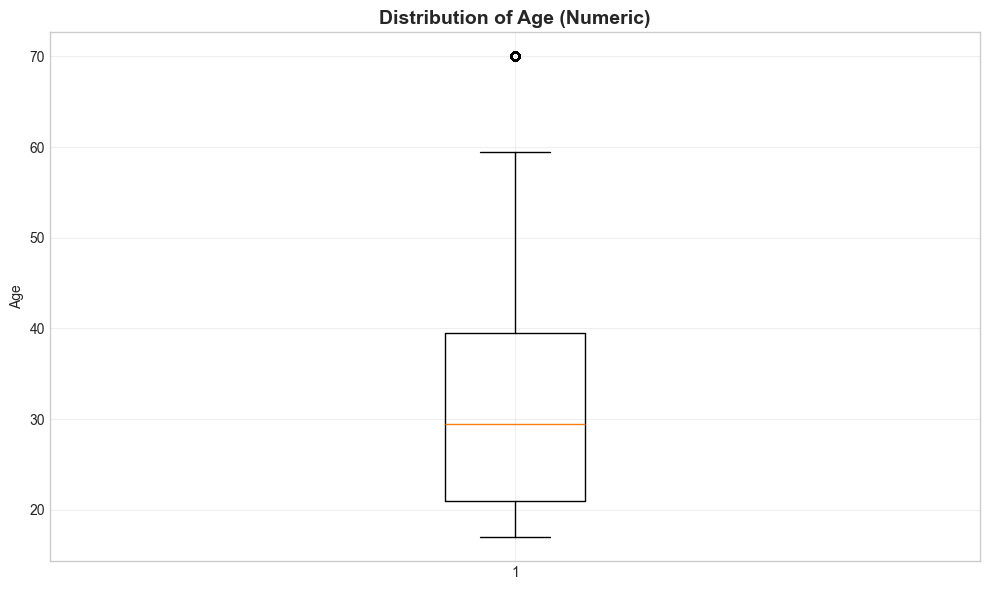

Median age: 29.5


In [24]:
# Query age data
QUERY = f"""
SELECT Age 
FROM {TABLE_NAME} 
WHERE Age IS NOT NULL
"""
age_data = pd.read_sql_query(QUERY, conn)

# Map age to numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

age_data['Age_Numeric'] = age_data['Age'].map(age_mapping)
age_data = age_data.dropna()

# Create box plot
plt.figure(figsize=(10, 6))
plt.boxplot(age_data['Age_Numeric'], vert=True)
plt.title('Distribution of Age (Numeric)', fontsize=14, fontweight='bold')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median age: {age_data['Age_Numeric'].median():.1f}")

## Task 2: Visualizing Relationships in Data

### Box Plot 3: Compensation by Age Group

I'll compare compensation distributions across different age groups.

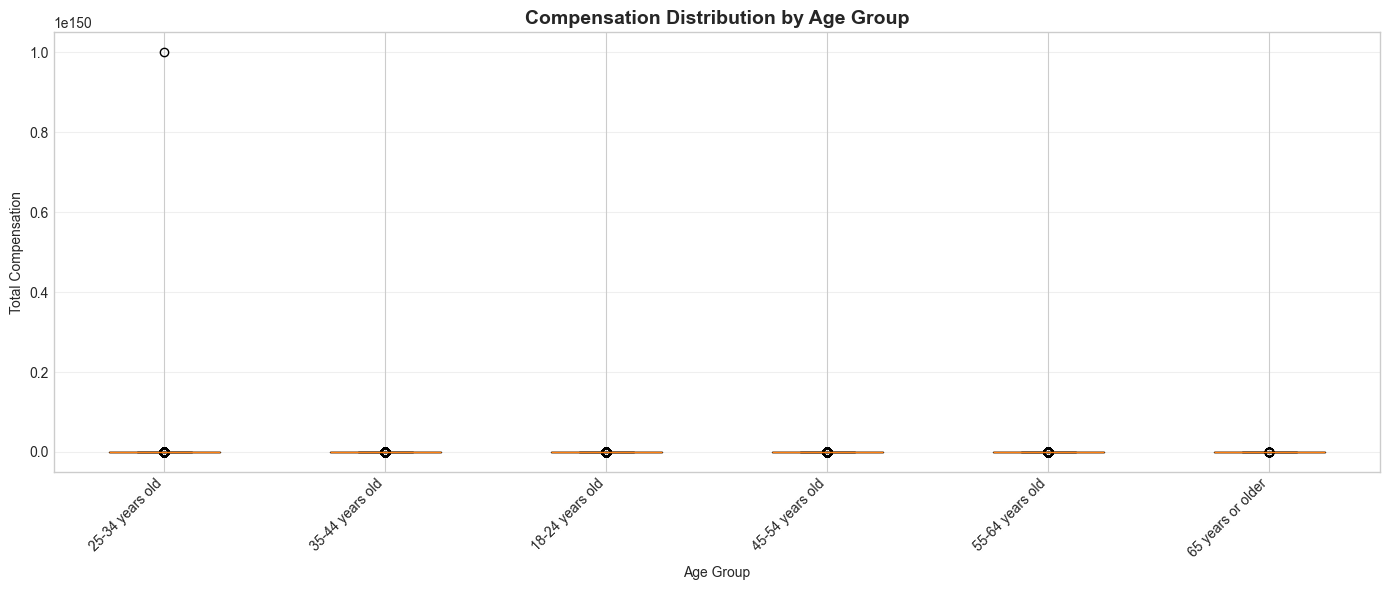

In [25]:
# Query compensation by age group
QUERY = f"""
SELECT Age, CompTotal 
FROM {TABLE_NAME} 
WHERE Age IS NOT NULL 
  AND CompTotal IS NOT NULL
"""
age_comp = pd.read_sql_query(QUERY, conn)

# Get top age groups
top_ages = age_comp['Age'].value_counts().head(6).index.tolist()
age_comp_filtered = age_comp[age_comp['Age'].isin(top_ages)]

# Prepare data for box plot
data_by_age = [age_comp_filtered[age_comp_filtered['Age'] == age]['CompTotal'].values 
               for age in top_ages]

# Create box plot
plt.figure(figsize=(14, 6))
plt.boxplot(data_by_age, tick_labels=top_ages)
plt.title('Compensation Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Box Plot 4: Compensation by Job Satisfaction

I'll examine how compensation varies based on job satisfaction levels.

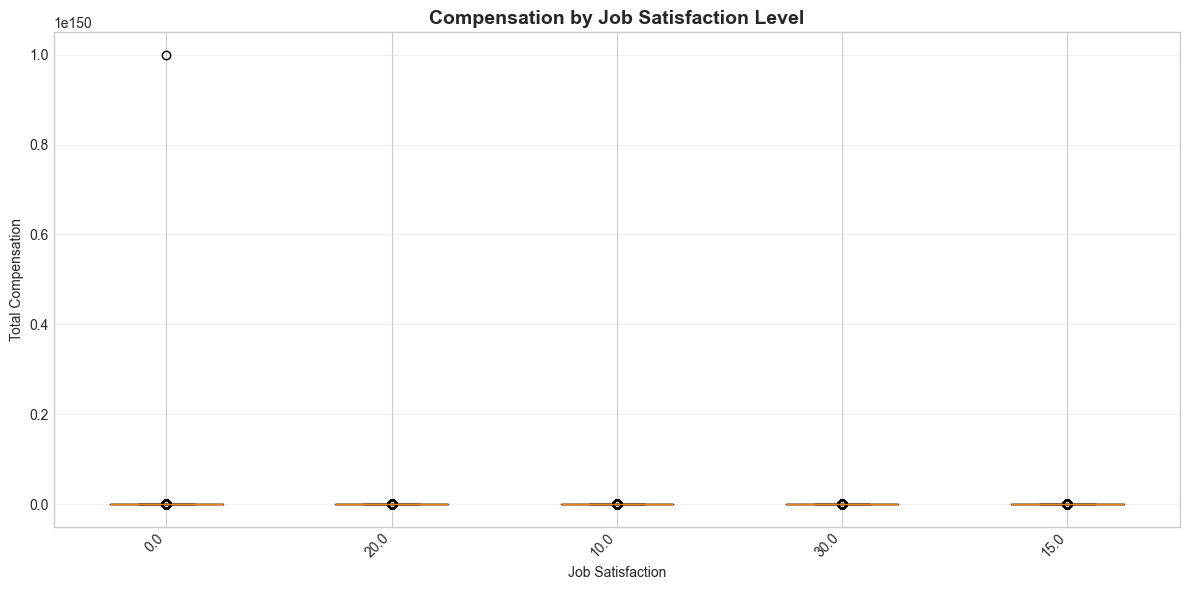

In [26]:
# Query compensation by job satisfaction
# Try different column names
jobsat_col = None
for col_name in ['JobSatPoints_6', 'JobSat']:
    try:
        QUERY = f"""
        SELECT {col_name}, CompTotal 
        FROM {TABLE_NAME} 
        WHERE {col_name} IS NOT NULL 
          AND CompTotal IS NOT NULL
        LIMIT 1
        """
        test = pd.read_sql_query(QUERY, conn)
        if len(test) > 0:
            jobsat_col = col_name
            break
    except:
        continue

# Query with the found column
QUERY = f"""
SELECT {jobsat_col}, CompTotal 
FROM {TABLE_NAME} 
WHERE {jobsat_col} IS NOT NULL 
  AND CompTotal IS NOT NULL
"""
jobsat_comp = pd.read_sql_query(QUERY, conn)

# Get satisfaction levels
sat_levels = jobsat_comp[jobsat_col].value_counts().head(5).index.tolist()
jobsat_comp_filtered = jobsat_comp[jobsat_comp[jobsat_col].isin(sat_levels)]

# Prepare data for box plot
data_by_sat = [jobsat_comp_filtered[jobsat_comp_filtered[jobsat_col] == level]['CompTotal'].values 
               for level in sat_levels]

# Create box plot
plt.figure(figsize=(12, 6))
plt.boxplot(data_by_sat, tick_labels=sat_levels)
plt.title('Compensation by Job Satisfaction Level', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Task 3: Visualizing Composition of Data

### Box Plot 5: Compensation by Developer Type

I'll analyze compensation across the top 5 developer roles.

In [27]:
# Query compensation by developer type
# Try different column names
dev_col = None
for col_name in ['DevType', 'MainBranch']:
    try:
        QUERY = f"""
        SELECT {col_name}, ConvertedCompYearly 
        FROM {TABLE_NAME} 
        WHERE {col_name} IS NOT NULL 
          AND ConvertedCompYearly IS NOT NULL
        LIMIT 1
        """
        test = pd.read_sql_query(QUERY, conn)
        if len(test) > 0:
            dev_col = col_name
            break
    except:
        continue

# Query with found column
QUERY = f"""
SELECT {dev_col}, ConvertedCompYearly 
FROM {TABLE_NAME} 
WHERE {dev_col} IS NOT NULL 
  AND ConvertedCompYearly IS NOT NULL
"""
dev_comp = pd.read_sql_query(QUERY, conn)

# Filter to respondents with a single developer type (no semicolons) for clean grouping
if dev_col == 'DevType':
    dev_comp = dev_comp[~dev_comp[dev_col].str.contains(';', na=False)]

# Get top 5 developer types
top_dev_types = dev_comp[dev_col].value_counts().head(5).index.tolist()
dev_comp_filtered = dev_comp[dev_comp[dev_col].isin(top_dev_types)]

# Prepare data for box plot
data_by_dev = [dev_comp_filtered[dev_comp_filtered[dev_col] == dev_type]['ConvertedCompYearly'].values 
               for dev_type in top_dev_types]

# Create box plot
plt.figure(figsize=(14, 6))
plt.boxplot(data_by_dev, tick_labels=top_dev_types)
plt.title('Compensation by Developer Type (Top 5)', fontsize=14, fontweight='bold')
plt.xlabel('Developer Type')
plt.ylabel('Yearly Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Box Plot 6: Compensation by Country

I'll analyze compensation across respondents from the top 5 countries.

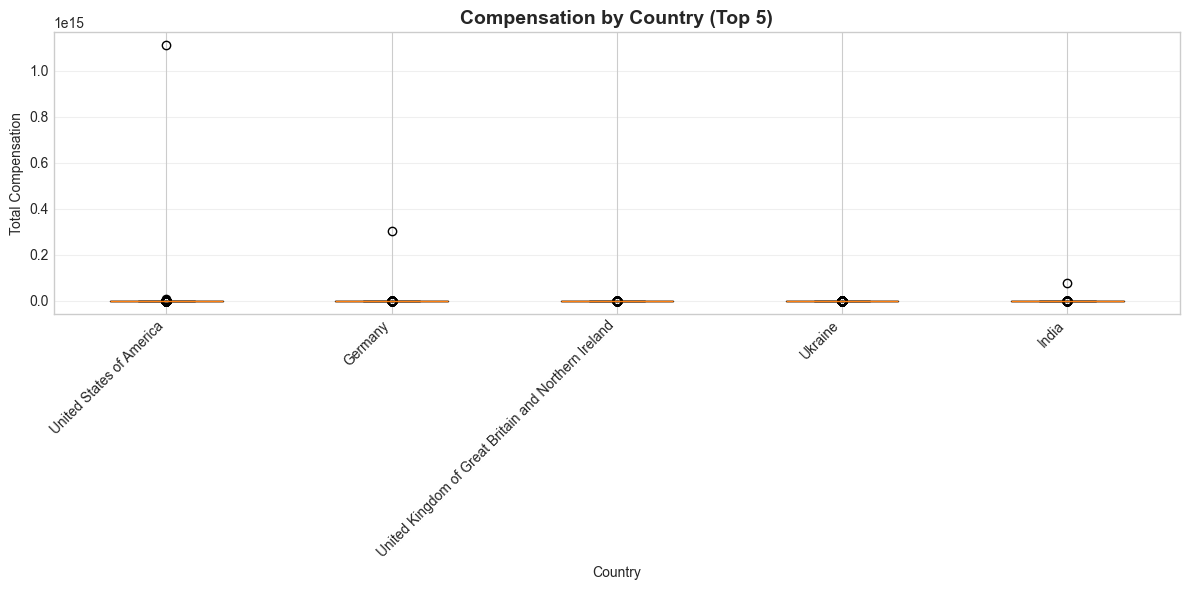

In [28]:
# Query compensation by country
QUERY = f"""
SELECT Country, CompTotal 
FROM {TABLE_NAME} 
WHERE Country IS NOT NULL 
  AND CompTotal IS NOT NULL
"""
country_comp = pd.read_sql_query(QUERY, conn)

# Get top 5 countries
top_countries = country_comp['Country'].value_counts().head(5).index.tolist()
country_comp_filtered = country_comp[country_comp['Country'].isin(top_countries)]

# Prepare data for box plot
data_by_country = [country_comp_filtered[country_comp_filtered['Country'] == country]['CompTotal'].values 
                   for country in top_countries]

# Create box plot
plt.figure(figsize=(12, 6))
plt.boxplot(data_by_country, tick_labels=top_countries)
plt.title('Compensation by Country (Top 5)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Task 4: Visualizing Comparison of Data

### Box Plot 7: Compensation by Employment Type

I'll analyze compensation for different employment types.

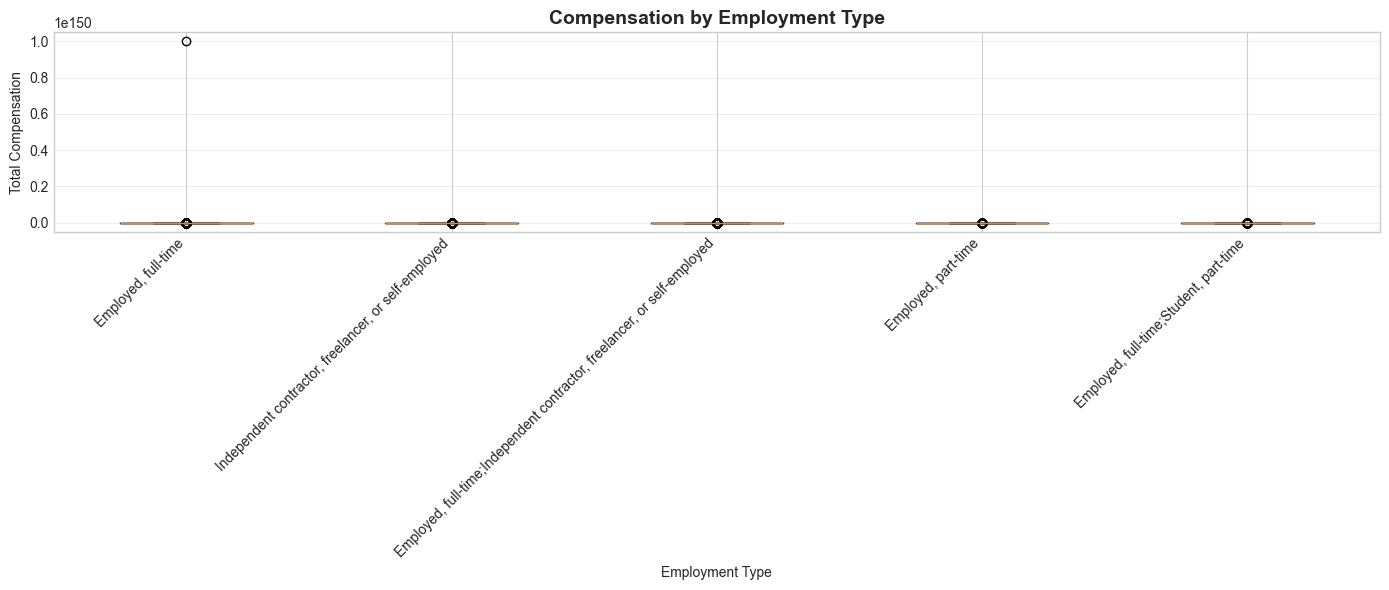

In [29]:
# Query compensation by employment type
QUERY = f"""
SELECT Employment, CompTotal 
FROM {TABLE_NAME} 
WHERE Employment IS NOT NULL 
  AND CompTotal IS NOT NULL
"""
emp_comp = pd.read_sql_query(QUERY, conn)

# Get top employment types
top_emp_types = emp_comp['Employment'].value_counts().head(5).index.tolist()
emp_comp_filtered = emp_comp[emp_comp['Employment'].isin(top_emp_types)]

# Prepare data for box plot
data_by_emp = [emp_comp_filtered[emp_comp_filtered['Employment'] == emp_type]['CompTotal'].values 
               for emp_type in top_emp_types]

# Create box plot
plt.figure(figsize=(14, 6))
plt.boxplot(data_by_emp, tick_labels=top_emp_types)
plt.title('Compensation by Employment Type', fontsize=14, fontweight='bold')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Box Plot 8: Years of Experience by Job Satisfaction

I'll examine the distribution of professional coding years by job satisfaction levels.

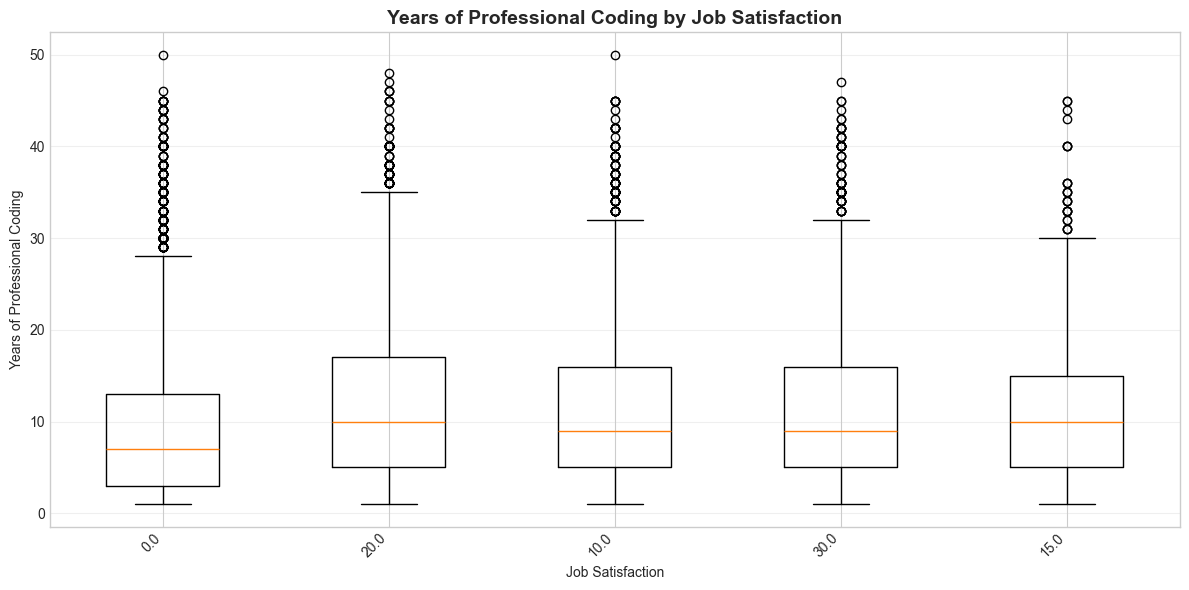

In [30]:
# Query years of experience by job satisfaction
QUERY = f"""
SELECT {jobsat_col}, YearsCodePro 
FROM {TABLE_NAME} 
WHERE {jobsat_col} IS NOT NULL 
  AND YearsCodePro IS NOT NULL
"""
jobsat_exp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
jobsat_exp['YearsCodePro'] = pd.to_numeric(jobsat_exp['YearsCodePro'], errors='coerce')
jobsat_exp = jobsat_exp.dropna()

# Get satisfaction levels
sat_levels_exp = jobsat_exp[jobsat_col].value_counts().head(5).index.tolist()
jobsat_exp_filtered = jobsat_exp[jobsat_exp[jobsat_col].isin(sat_levels_exp)]

# Prepare data for box plot
data_by_sat_exp = [jobsat_exp_filtered[jobsat_exp_filtered[jobsat_col] == level]['YearsCodePro'].values 
                   for level in sat_levels_exp]

# Create box plot
plt.figure(figsize=(12, 6))
plt.boxplot(data_by_sat_exp, tick_labels=sat_levels_exp)
plt.title('Years of Professional Coding by Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction')
plt.ylabel('Years of Professional Coding')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Closing the Database Connection

Finally, I'll close the database connection.

In [31]:
# Close the database connection
conn.close()
print("✅ Database connection closed")

✅ Database connection closed


## Summary

In this notebook, I used box plots to analyze various aspects of the developer survey data:

- **Distribution visualization** - Identified outliers and spread in compensation and age
- **Relationship analysis** - Compared compensation across age groups and job satisfaction levels
- **Composition analysis** - Examined compensation by developer types and countries
- **Comparison analysis** - Analyzed compensation by employment type and experience by satisfaction

Box plots are particularly useful for:
- Identifying outliers in the data
- Understanding the spread and central tendency
- Comparing distributions across multiple groups
- Spotting skewness in the data

These visualizations revealed patterns in compensation, experience, and satisfaction across different demographic and professional segments of the developer community.